In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# i am god

np.random.seed(42)
TRUE_SLOPE = 0.5       # MPa per meter of depth
TRUE_INTERCEPT = 20.0  # MPa at surface
TRUE_SIGMA = 4.0       # Measurement noise but not saying due to sensor error

# saying that inherent variation of nature prevents perfect measurement
# aleatoric uncertainity    

n = 50
depth = np.random.uniform(10, 100, n)

ucs = TRUE_INTERCEPT + TRUE_SLOPE * depth + np.random.normal(0, TRUE_SIGMA, n)

plt.scatter(depth, ucs, alpha=0.6)
plt.xlabel("Depth (m)")
plt.ylabel("UCS (MPa)")
plt.title("Rock Strength vs Depth")
plt.tight_layout()
plt.show()


In [ ]:
# simple model

with pm.Model() as regression_model:

    # prior: how does the ucs vary with depth; weakly informative, we expect positive (overburden)

    slope = pm.HalfNormal("slope", sigma=1)
    intercept=pm.Lognormal("intercept", mu = np.log(25), sigma=0.55)

# for mu we can cuz its addititive -> multiplicative; center shifting
# sigma!= np.log(15) as it acts as an exponential multiplier
# 0.1 is tight, 0.3 is moderate, and 0.5 to 1.0 is extremely wide/uncertain.
# e^sigma times differ from mu

    sigma = pm.HalfNormal("sigma", sigma = 0.5)
    # value in mind, depending on distro we use on y



    exp_ucs = pm.Deterministic("exp_ucs", intercept+slope*depth)
    # what happens if i dont specify pm.det and only say mu = ... ?

    y = pm.Lognormal("y", mu=pm.math.log(exp_ucs), sigma=sigma, observed=ucs)

    # pm.math to keep with the blueprint vibes, np demands numbers RN


In [ ]:
# perform prior predictive checks

with regression_model:
    prior_checks = pm.sample_prior_predictive(samples=1000, random_seed=42)


fig, ax = plt.subplots(figsize=(12, 6))
az.plot_ppc(prior_checks,
group="prior",
kind="kde",
ax=ax,
colors=['gray', 'black', 'blue'], alpha=0.8) # [Prior, Mean, Observed]


az.plot_kde(ucs, ax=ax, plot_kwargs={"color": "red", "linewidth": 3, "linestyle": "--"}, label="Actual Observed Data")

ax.set_title("Prior Predictive Check: Physicality Audit", fontsize=14, fontweight='bold')
ax.set_xlabel("UCS", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)


ax.set_xlim(-10, max(ucs) * 2.5)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x_plot = np.linspace(0, 120, 100)

# Extract prior samples for slope and intercept
prior_slopes = prior_checks.prior["slope"].values.flatten()
prior_intercepts = prior_checks.prior["intercept"].values.flatten()


for i in range(50):
    y_line = prior_intercepts[i] + prior_slopes[i] * x_plot
    ax.plot(x_plot, y_line, 'gray', alpha=0.1)

ax.scatter(depth, ucs, c='blue', zorder=5, label='Actual data')

ax.set_xlabel("Depth (m)")
ax.set_ylabel("Expected UCS (MPa)")
ax.set_title("Prior Predictive: Do my prior LINES look reasonable?")

# Constrain the Y-axis so extreme priors don't ruin the scale
ax.set_ylim(-10, max(ucs) * 2)

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
with regression_model:
    trace = pm.sample(2000, tune=1000, chains = 2, cores=2, random_seed=42, progressbar=False)



az.plot_trace(trace, var_names=["slope", "intercept", "sigma"],
              compact=True,
              kind="trace")
plt.suptitle("Convergence Check: Trace Plots")
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["slope", "intercept", "sigma"]))

display(pm.model_to_graphviz(regression_model))

In [ ]:
with regression_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42, progressbar=False)


az.plot_ppc(ppc, observed_rug=True, kind="cumulative")
plt.title("Posterior Predictive Check: Model vs Reality")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Extract posterior samples
post_slopes = trace.posterior["slope"].values.flatten()
# flattening the (2,2000) dimension
post_intercepts = trace.posterior["intercept"].values.flatten()

for i in range(0, len(post_slopes), len(post_slopes) // 100): # modulo filter here, since 100 lines plottting
    y_line = post_intercepts[i] + post_slopes[i] * x_plot
    ax.plot(x_plot, y_line, 'red', alpha=0.05)

# The MEAN line
mean_slope = post_slopes.mean()
mean_intercept = post_intercepts.mean()
ax.plot(x_plot, mean_intercept + mean_slope * x_plot, 'g-', linewidth=2, label='Mean posterior line')

ax.scatter(depth, ucs, c='blue', zorder=5, label='Data')
ax.set_xlabel("Depth (m)")
ax.set_ylabel("UCS (MPa)")
ax.set_title("Posterior: Distribution of Plausible Lines")
ax.legend()
plt.tight_layout()
plt.show()

print(f"True slope: {TRUE_SLOPE}, Estimated: {mean_slope:.3f}")
print(f"True intercept: {TRUE_INTERCEPT}, Estimated: {mean_intercept:.3f}")

In [ ]:
from sklearn.linear_model import LinearRegression

# Frequentist fit
lr = LinearRegression().fit(depth.reshape(-1, 1), ucs)
print(f"Scikit-learn: slope={lr.coef_[0]:.3f}, intercept={lr.intercept_:.3f}")
print(f"PyMC Mean:    slope={mean_slope:.3f}, intercept={mean_intercept:.3f}")
print(f"PyMC 94% HDI: slope={az.hdi(trace, var_names=['slope']).to_dataframe().values}")

# for 'perfect' synth data, they do converge but to estimate our actual ignorance pymc is king


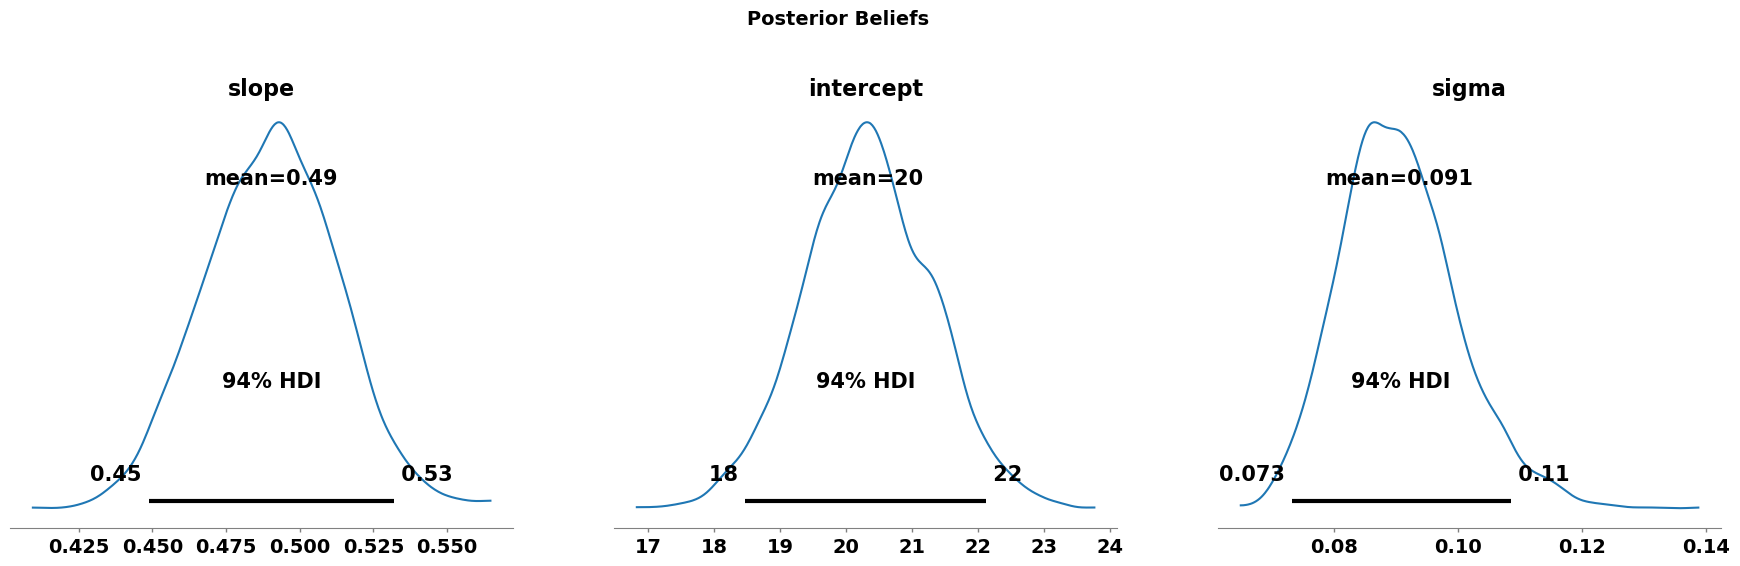

In [88]:
# The Posterior Presentation Graph
az.plot_posterior(trace, var_names=["slope", "intercept", "sigma"], hdi_prob=0.94)
plt.suptitle("Posterior Beliefs", y=1.05, fontsize=14)
plt.show()

In [ ]:
# comparisoin of posterrior regr lines distro for diff n

sparse_idx = np.random.choice(n, size=5, replace=False)
depth_sparse = depth[sparse_idx]
ucs_sparse = ucs[sparse_idx]

with pm.Model() as sparse_model:
    slope = pm.HalfNormal("slope", sigma=1)
    intercept = pm.Lognormal("intercept", mu=np.log(25), sigma=0.55)
    sigma = pm.HalfNormal("sigma", sigma=0.5)

    exp_ucs = pm.Deterministic("exp_ucs", intercept + slope * depth_sparse)
    y = pm.Lognormal("y", mu=pm.math.log(exp_ucs), sigma=sigma, observed=ucs_sparse)

    trace_sparse = pm.sample(2000, tune=1000, chains=2, cores=2, random_seed=42, progressbar=False)

# Visual Comparison: n=50 (Rich Data) vs n=5 (Sparse Data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x_plot = np.linspace(0, 120, 100)

# Left Plot: Full Data (n=50)
axes[0].scatter(depth, ucs, c='blue', zorder=5)
for i in range(100):
    s, ic = post_slopes[i*40], post_intercepts[i*40]
    axes[0].plot(x_plot, ic + s * x_plot, 'red', alpha=0.05)
axes[0].set_title(f"n=50: The 'Safe' Baseline")
axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel("UCS (MPa)")

# Right Plot: Sparse Data (n=5)
# Extract posterior samples from the sparse model
sparse_slopes = trace_sparse.posterior["slope"].values.flatten()
sparse_intercepts = trace_sparse.posterior["intercept"].values.flatten()

axes[1].scatter(depth_sparse, ucs_sparse, c='blue', zorder=5)
for i in range(100):
    s, ic = sparse_slopes[i*40], sparse_intercepts[i*40]
    axes[1].plot(x_plot, ic + s * x_plot, 'orange', alpha=0.05)
axes[1].set_title(f"n=5: The 'Dangerous' Baseline")
axes[1].set_xlabel("Depth (m)")

plt.tight_layout()
plt.show()